# Claims Data Analysis

1. Run an initial EDA and share with us your observations on the different members
and corresponding services listed in the claims data


2. Given the ‘claimstatus’ and ‘auto_approved_claim’ columns. What can you tell us
about their relationship and use? Do you think the model generating the
‘auto_approved’ results is doing a good job?
  - Auto Approvals are primarily standard coverage and preventive care services
  - This suggests the model is designed to handle low-risk standard cases.
  - Auto approved claims account for 191 of the total 1022 claims. This is ~20% of the total claims
  - The model performs well but the majority of the claims still require manual review meaning that the model could improve by taking more workload.


3. Part of our work is to handle text and, most of the time, this text is an
observation/comment provided by a claim reviewer on why the claim is approved,
denied, or pending for a given member. Could you tell us the top five reasons why
claims are being approved? Could you tell us the top five reasons why claims are
being denied?

> Based on text analysis, word frequencies, and k-means clustering we can Identify with confidence some categories/top reasons for claim approval and denial.
- Approval Top 5:
  - Policy Requirements Met
  - Documentation & Network Compliance
  - Supported within Policy Limits
  - Standard Coverage Preventive Service
  - Meets Coverage Eligibility

- Denial Top 5:
  - Policy Requirements Not Met
  - Insufficient Documentation
  - Policy Exclusion
  - Non-Compliance
  - Missing Justification


4. Could you tell us anything else about the claims data? Do you have additional
findings that will be helpful to further discover and pursuit?
  - Evaluating claims over time can drive insights to what times of year process the largest volumes and detect dips in claim submissions.
  - Why is there are large spike in claims at the beginning of Q2?
  - We explored methods in topic modeling to classify and group the reasoning text behind both approval and denial claims.
  - This method proved to be effective at grouping reasons similar phrases into groups but was overly complex for our current use case and problem.
  - This may be worth exploring in more detail for additional research.


##Imports and Load Data


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Explore Data
- Claims data, each row shows a members claim, service provided, their providers id, claim status and the reviewer.

In [ ]:
df = pd.read_csv('/content/AI-Eng-Data-Challenge.csv')
df

,claim_id,member_name,service,submission_date,provider_id,claimstatus,auto_approved_claim,clinical_reviewer,member_id,reason
0,001d0f43-33a2-4add-b8a8-2b32b73ef318,Sophie,Vaccination,2/24/2024 14:26,1008,Approved,False,NaN,MBR-1953,Full coverage approved: Routine annual immuniz...
1,003031d6-cf95-4c0c-b0f2-06c89dff726f,Harper,Lab Test,11/26/2023 14:26,1006,Approved,False,NaN,MBR-8260,Approved: Laboratory panel (3 units) is medica...
2,003fae46-1e76-4aba-8670-95d9dabf1848,Gunther,Vaccination,7/17/2024 14:26,1002,Approved,False,NaN,MBR-1854,Approved: Multi-dose viral series (4 units) fu...
3,004389e2-75b9-484d-ab9b-cd9b00e8af4f,Thomas,X-ray,4/25/2024 14:26,1003,Denied,False,NaN,MBR-7814,Denied: Duplicate service submission; initial ...
4,004e13f1-d8ed-4e32-8d3d-886764f7835b,Roxy,Dental Cleaning,9/25/2023 14:26,1019,Denied,False,NaN,MBR-4027,Denied: Frequency limit exceeded; last dental ...
...,...,...,...,...,...,...,...,...,...,...
1017,5640012e-ce13-401f-b77a-832a9afc9c3d,Cooper,X-ray,1/8/2024 14:26,1014,Denied,False,NaN,MBR-7513,Policy requirements not met.
1018,564eaadf-53a5-4fac-8cec-38a71ff32198,Missy,Vaccination,3/24/2024 14:26,1016,Approved,False,NaN,MBR-5837,Meets all policy requirements.
1019,565ae44c-f90f-421f-8909-4e800e4f1b8a,Nike,Check-up,1/2/2024 14:26,1007,Approved,False,NaN,MBR-1197,Meets all policy requirements.
1020,56697a32-ae59-4c0b-b3f6-47d330bd8e0a,Lizzy,Lab Test,4/4/2024 14:26,1003,Approved,False,NaN,MBR-7824,Meets all policy requirements.


## Initial Questions:

#### Cleaning
- [x] Are there Missing values?
- [x] Duplicate claims?


#### Analytics & Understanding:
- [x] What is the total number of claims Approved / Denied / Pending?
- [x] Overall distribution (amount of claims) of services, providers, and members (high risk members)?
- [x] Trend of claims over time?
- [x] How many claims are auto approved and how many are not?

#### Metrics & NLP
- [x] What is the approval rate and denial rate for each of the following categories; Service, Member_id, Provider_id.
- [x] 5 most common phrases among approved and denied?



### Additional Notes & Questions
- With Age we could look at number of claims in different age brackets.
- Approved claims, Indicates operational success and customer fulfillment
- Rejected claims, high rejections may indicate policy mismatches, fraud, or documentation issues. May provide insights into what needs to be changed, may damage customer satisfaction.
- Pending claims, operational bottlenecks, hanging resolutions. Points to where tuning and automation may be helpful.

- Important to identify high risk members for future costs.
- Providers with high denial rates could indicate poor documentation or potentially fraud.
- Members with high denial rate may point to plan mismatch due to policy issues.
- Reviewers can show stricter decision making or processing inconsistencies.



In [ ]:
#lets check the missing values and for duplicate records.
print(df.shape)

#Convert date to usable object
df['submission_date'] = pd.to_datetime(df['submission_date'])


missing = df.isna().sum().reset_index(name='missing_values')
full_dupes = df.duplicated().sum()
id_dupes = df['claim_id'].duplicated().sum()

print("Full Row Duplicate Values: ", full_dupes)
print("ID Duplicate Values: ", id_dupes)
display(missing)
#Data looks very clean, missing reviewers does not cause an issue here.

(1022, 10)
Full Row Duplicate Values:  0
ID Duplicate Values:  0


,index,missing_values
0,claim_id,0
1,member_name,0
2,service,0
3,submission_date,0
4,provider_id,0
5,claimstatus,0
6,auto_approved_claim,0
7,clinical_reviewer,715
8,member_id,0
9,reason,0


### Services Summary

In [ ]:

#get an understanding of claim counts and stats
totals = df['claimstatus'].value_counts().reset_index()
totals['percent_count'] = 100*(totals['count']/totals['count'].sum()).round(3)


#distribution of types of service
service_dist = df.service.value_counts().reset_index()
service_dist['percent_count'] = 100*(service_dist['count']/service_dist['count'].sum()).round(3)

#approval, denial and pending rate
service_stat = df.groupby('service')['claimstatus'].value_counts().unstack()
service_stat = service_stat.reset_index()

service_summary = service_dist.join(service_stat.set_index('service'), on='service')
service_summary = service_summary.fillna(0)


display(totals)
display(service_summary)

,claimstatus,count,percent_count
0,Approved,705,69.0
1,Denied,275,26.9
2,Pending,42,4.1


,service,count,percent_count,Approved,Denied,Pending
0,Check-up,295,28.9,293.0,2.0,0.0
1,X-ray,198,19.4,72.0,115.0,11.0
2,Vaccination,168,16.4,125.0,34.0,9.0
3,Dental Cleaning,158,15.5,76.0,73.0,9.0
4,Lab Test,107,10.5,83.0,14.0,10.0
5,Surgery,96,9.4,56.0,37.0,3.0


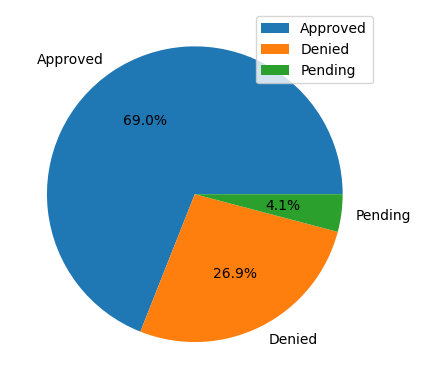

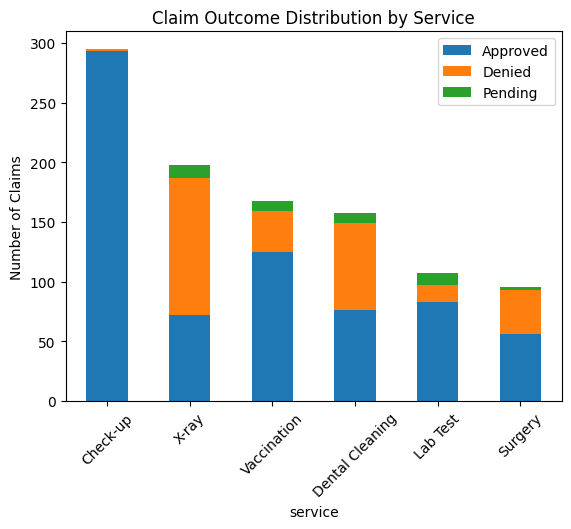

In [ ]:
#Pie chart for total approval, denial, and pending
totals.set_index('claimstatus').plot.pie(y='percent_count', autopct='%1.1f%%', ylabel='')
#services bar chart 3 classes for each category. approved, denied, pending. Normalize counts above for %.
ax = service_summary.plot(x="service", y=["Approved", "Denied", "Pending"], kind="bar",stacked=True, rot=45)
plt.ylabel("Number of Claims")
plt.title("Claim Outcome Distribution by Service")
plt.show()

In [ ]:
#Why are there 2 checkups denied?
df[(df['claimstatus']=='Denied') & (df['service']=='Check-up')]

,claim_id,member_name,service,submission_date,provider_id,claimstatus,auto_approved_claim,clinical_reviewer,member_id,reason
151,0d25589f-7e1e-42ab-902d-785ce2114128,Alexander,Check-up,2023-11-29 14:26:00,1001,Denied,False,Leah Duncan,MBR-5793,Policy requirements not met.
384,1f2d3fe2-6767-4159-99d7-5f88c8beeb3b,Stella,Check-up,2024-07-08 14:26:00,1007,Denied,False,NaN,MBR-7388,Denied: Claim for Check-up for Member ID MBR-7...


In [ ]:
#why are X-rays often denied?
df[(df['claimstatus']=='Denied') & (df['service']=='X-ray')]

,claim_id,member_name,service,submission_date,provider_id,claimstatus,auto_approved_claim,clinical_reviewer,member_id,reason
3,004389e2-75b9-484d-ab9b-cd9b00e8af4f,Thomas,X-ray,2024-04-25 14:26:00,1003,Denied,False,NaN,MBR-7814,Denied: Duplicate service submission; initial ...
5,0063b8f5-a902-4999-badd-90a94957bb8a,Taz,X-ray,2024-05-27 14:26:00,1008,Denied,False,NaN,MBR-9503,Denied: Imaging (3 units) lacks supporting cli...
6,006b52b2-c6cf-4e6b-b8bf-abb99a06248f,Anthony,X-ray,2023-12-22 14:26:00,1006,Denied,False,Ellen Atkinson,MBR-7730,Denied: Service (2 units) provided by an out-o...
20,01437dab-c431-4c28-9fab-ca2535e3b2c8,Harper,X-ray,2024-03-04 14:26:00,1000,Denied,False,NaN,MBR-8260,Denied: Policy excludes coverage for post-trea...
24,019e0f7f-4c3a-4ef5-b40a-f57590221ac1,Theo,X-ray,2024-04-16 14:26:00,1000,Denied,False,Bruce Campbell,MBR-4033,Denied: Radiographic study (2 units) is non-di...
...,...,...,...,...,...,...,...,...,...,...
982,53ec86dd-d634-4b5c-8d26-5e8ed09afb12,Bear,X-ray,2023-11-03 14:26:00,1017,Denied,False,NaN,MBR-5946,Denied: Unique reason with specific policy exc...
992,54c23007-d2d7-413f-bb52-70845120c05c,Oliver,X-ray,2024-05-04 14:26:00,1018,Denied,False,NaN,MBR-1326,Denied: Unique reason with specific policy exc...
994,54e87ae7-0490-481c-a32d-407f8d4834a4,Silvia,X-ray,2023-11-07 14:26:00,1001,Denied,False,NaN,MBR-8832,Denied: Unique reason with specific policy exc...
1012,5603b4a4-3f61-4116-930b-4c3f5112caca,Sasha,X-ray,2023-12-12 14:26:00,1013,Denied,False,Lincoln Sampson,MBR-1415,Denied: Unique reason with specific policy exc...


### Members Summary

In [ ]:
#top 5 most common providers
provider_dist = df.provider_id.value_counts().reset_index()
provider_stat = df.groupby('provider_id')['claimstatus'].value_counts(normalize=True).unstack().reset_index()
provider_summary = provider_dist.join(provider_stat.set_index('provider_id'), on='provider_id')
provider_summary = provider_summary.fillna(0)
display(provider_summary.head())

#top 5 members with highest claim count
member_dist = df.member_id.value_counts().reset_index()
member_stat = df.groupby('member_id')['claimstatus'].value_counts().unstack().reset_index()
member_summary = member_dist.join(member_stat.set_index('member_id'), on='member_id')
member_summary = member_summary.rename(columns={"count":"Claims_Count"})

,provider_id,count,Approved,Denied,Pending
0,1008,56,0.660714,0.303571,0.035714
1,1006,56,0.821429,0.160714,0.017857
2,1005,56,0.732143,0.232143,0.035714
3,1013,56,0.660714,0.321429,0.017857
4,1018,54,0.648148,0.296296,0.055556


In [ ]:
#What services do each member use most
member_service_count = df.groupby(['member_id'])['service'].value_counts().unstack().reset_index()
member_summary = member_summary.join(member_service_count.set_index('member_id'), on='member_id')
round_this = ['Approved', 'Denied', 'Pending']
for col in round_this:
  member_summary[col] = member_summary[col].round(3)
member_summary = member_summary.fillna(0)
member_summary

,member_id,Claims_Count,Approved,Denied,Pending,Check-up,Dental Cleaning,Lab Test,Surgery,Vaccination,X-ray
0,MBR-2366,16,12.0,4.0,0.0,7.0,2.0,1.0,2.0,2.0,2.0
1,MBR-3458,15,10.0,5.0,0.0,5.0,2.0,0.0,2.0,1.0,5.0
2,MBR-5992,13,8.0,5.0,0.0,4.0,3.0,1.0,1.0,2.0,2.0
3,MBR-4079,13,13.0,0.0,0.0,6.0,4.0,0.0,0.0,0.0,3.0
4,MBR-4027,12,6.0,6.0,0.0,2.0,4.0,0.0,0.0,4.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...
152,MBR-7252,3,3.0,0.0,0.0,2.0,0.0,0.0,0.0,1.0,0.0
153,MBR-8260,2,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
154,MBR-2756,2,1.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
155,MBR-7239,2,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0


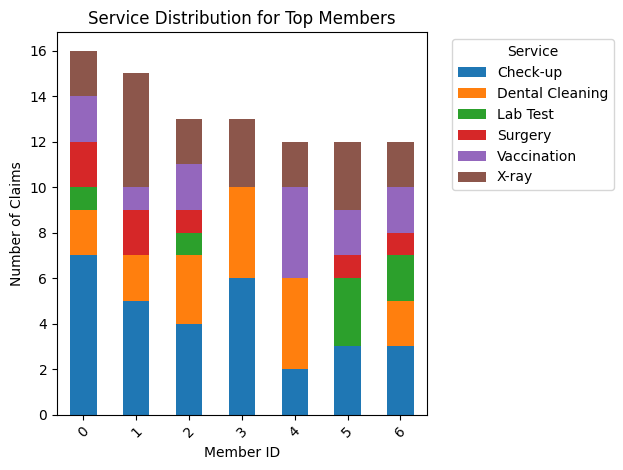

In [ ]:
# Select only service columns
top_members = member_summary.head(7)
services = ['Check-up', 'Dental Cleaning', 'Lab Test', 'Surgery', 'Vaccination', 'X-ray']
service_data = top_members[services]

# Plot stacked bar chart
service_data.plot(kind='bar', stacked=True)

plt.xlabel("Member ID")
plt.ylabel("Number of Claims")
plt.title("Service Distribution for Top Members")
plt.xticks(rotation=45)

plt.legend(title="Service", bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

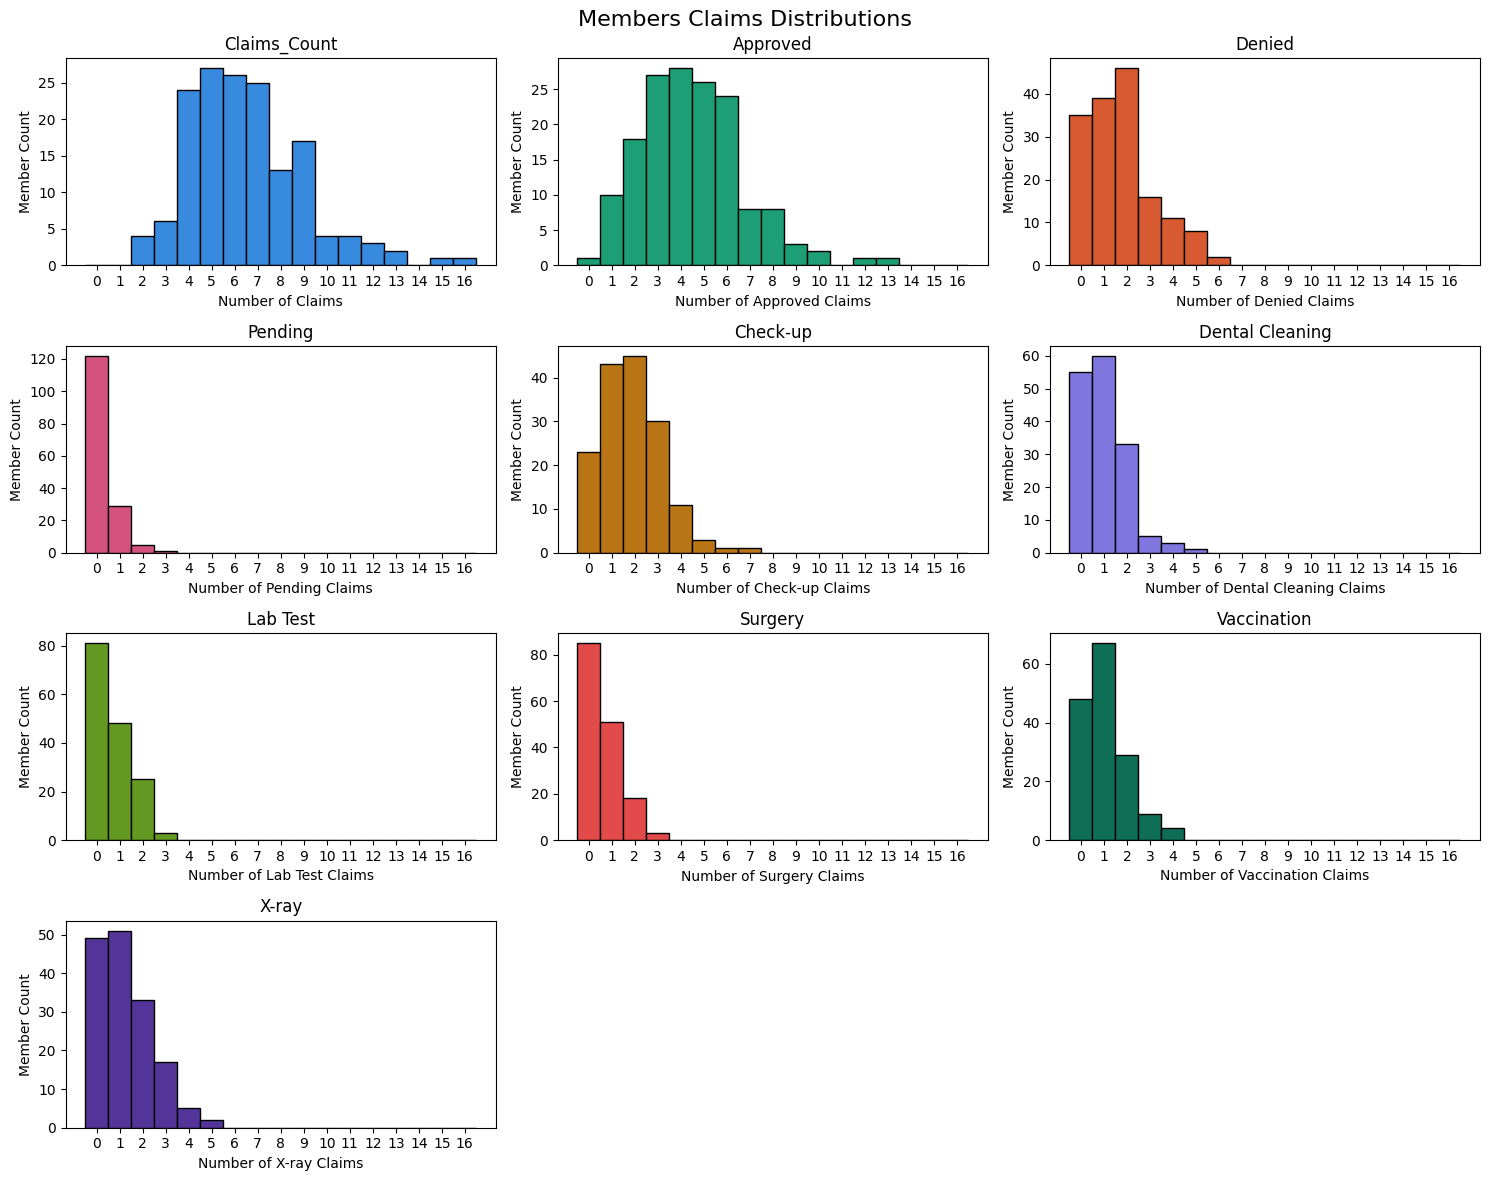

In [ ]:
#histograms, how many checkups are autoapproved?
# Select only numeric columns
num_cols = member_summary.select_dtypes(include='number').columns
# Create grid
n_cols = 3
n_rows = (len(num_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 3 * n_rows))
axes = axes.flatten()
colors = [
    '#378ADD','#1D9E75','#D85A30','#D4537E','#BA7517',
    '#7F77DD','#639922','#E24B4A','#0F6E56','#533498'
]
fig.suptitle('Members Claims Distributions', fontsize=16)
for i, col in enumerate(num_cols):
    max_val = int(member_summary[col].max())

    # bins = range(0, max_val + 2)  # +2 to include last bin edge
    bins = range(0, 16 + 2)
    axes[i].hist(
        member_summary[col],
        bins=[b - 0.5 for b in bins],  # center bars on integers
        color=colors[i],
        edgecolor='black'
    )
    axes[i].set_xticks(range(0, 16 + 1))  # discrete integer ticks
    axes[i].set_title(col)
    if col == 'Claims_Count':
      axes[i].set_xlabel(f"Number of Claims")
    else:
      axes[i].set_xlabel(f"Number of {col} Claims")
    axes[i].set_ylabel("Member Count")


# Remove empty plots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


In [ ]:
#sanity check
member_summary['Claims_Count'].sum()

np.int64(1022)

### Claims over time

2023-08-20 14:26:00 2024-08-19 14:26:00


Text(0, 0.5, 'claims_count')

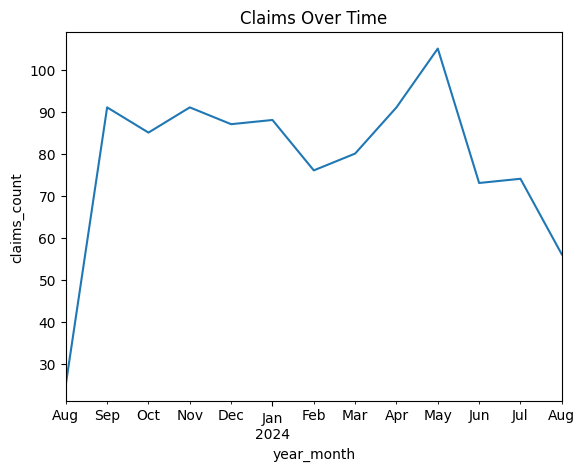

In [ ]:
#looking through aug-2023 to aug-2024
print(df.submission_date.min(), df.submission_date.max())
df['year_month'] = df.submission_date.dt.to_period('M')
monthly_counts = (df.groupby('year_month').size())
monthly_counts.plot(title='Claims Over Time', x='year_month', y='claims count', kind='line')
plt.ylabel("claims_count")

## 1. Observations

- We have a clean claims dataset with no missing values or duplicate records. (Aside from the reviewer column)
- We explored the total Approved, Denied, and Pending claims, we can see a distribution of ~ 69% approved, 27% denied, and 4% pending.
- Looking into each service we find where the claims fall under each category, we can see that nearly all the Check-Up services were approved with 2 policy related denials. X-Ray, dental_cleaning and surgery services have the highest denial rates, this could be due to policy issues or non-essential services and could be candidates for additional research.
- X-ray denials seem to be largely due to policy requirements not being met. This may indicate a need for change in policy to improve customer satisfaction.
- Additionally with the member summary table we can see which members have high denial rates, high number of claims, and their corresponding services. This indicates which members are high risk, potential plan mismatch with high denial rates, and the common services each member undergoes.


## Claims Status & Auto Approved Claims
- To compare and identify the relationship between 'claimstatus' and 'auto_approved_claim', I determined the distribution of auto approved claims and the number of auto approved claims for each service.
- Auto approved claims are primarily standard coverage and **preventive care services** suggesting the model is designed to handle low-risk standard cases.
- The manually decided claims are generally more ambiguous and more complex scenarios.
- After comparing the approval rate of manual and auto approved claims, the model accurately handles the simple and more standard claims they only occount for 191 of the total 1022 claims. This is ~20% of the total claims meaning majority of the claims still require manual review.

In [ ]:
# lets review the auto approved claims and determine the effectiveness.
auto_claims_count = df.groupby('auto_approved_claim').size().reset_index(name='claims_count')
display(auto_claims_count)


#what types of service does the auto review approve mainly
auto_service_count = df[df['auto_approved_claim']==True].groupby(['service']).size().reset_index(name='auto_approved_count')
manual_service_count = df[df['auto_approved_claim']==False].groupby(['service']).size().reset_index(name='manually_decided')
auto_claim_summary = auto_service_count.join(manual_service_count.set_index('service'), on='service')
auto_claim_summary['auto_claim_percent'] = 100*(auto_claim_summary['auto_approved_count']/(auto_claim_summary['manually_decided']+auto_claim_summary['auto_approved_count']))
auto_claim_summary

,auto_approved_claim,claims_count
0,False,831
1,True,191


,service,auto_approved_count,manually_decided,auto_claim_percent
0,Check-up,92,203,31.186441
1,Dental Cleaning,6,152,3.797468
2,Lab Test,27,80,25.233645
3,Surgery,2,94,2.083333
4,Vaccination,37,131,22.023810
5,X-ray,27,171,13.636364


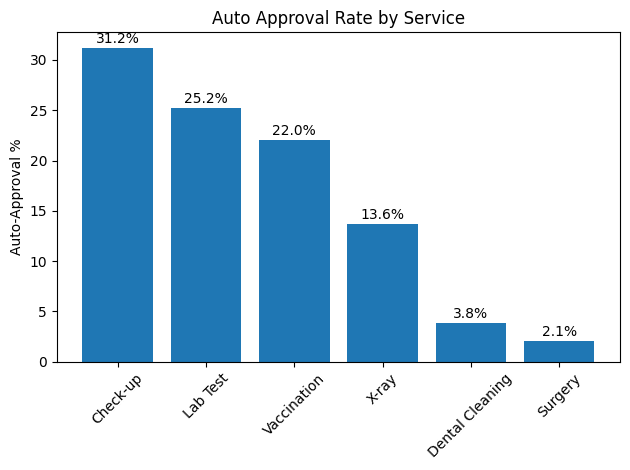

In [ ]:
auto_claim_summary = auto_claim_summary.sort_values("auto_claim_percent", ascending=False)

plt.figure()
plt.bar(auto_claim_summary["service"], auto_claim_summary["auto_claim_percent"])
plt.xticks(rotation=45)
plt.ylabel("Auto-Approval %")
plt.title("Auto Approval Rate by Service")

for i, v in enumerate(auto_claim_summary["auto_claim_percent"]):
    plt.text(i, v + 0.5, f"{v:.1f}%", ha='center')

plt.tight_layout()
plt.show()

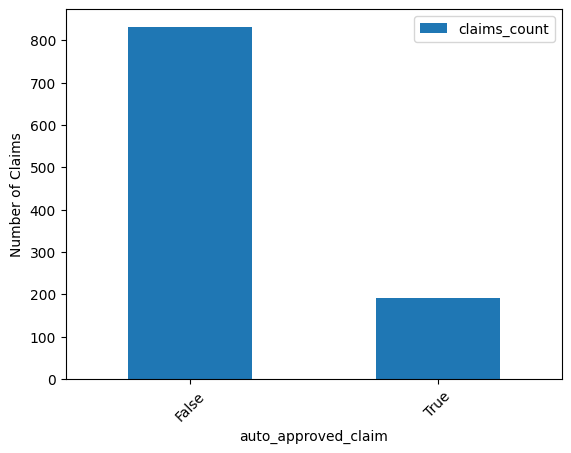

In [ ]:
ax = auto_claims_count.plot(x="auto_approved_claim", y='claims_count', kind="bar", rot=45)
plt.ylabel("Number of Claims")
plt.show()

In [ ]:
auto_approved = df[df['auto_approved_claim']==True]
display(auto_approved)

,claim_id,member_name,service,submission_date,provider_id,claimstatus,auto_approved_claim,clinical_reviewer,member_id,reason,year_month
9,00782d5e-0960-400c-9fae-1c4cb16bd091,Jake,Lab Test,2024-06-12 14:26:00,1020,Approved,True,NaN,MBR-9578,Approved: High-volume metabolic panel (3 units...,2024-06
10,007e91a5-6260-4d69-bd60-1e3e0d8e9677,Alice,Lab Test,2023-12-23 14:26:00,1008,Approved,True,NaN,MBR-2923,Approved: Single therapeutic drug monitoring t...,2023-12
18,013728bb-cd98-421c-9512-71ee9e3c412c,Prince,Check-up,2023-10-12 14:26:00,1008,Approved,True,NaN,MBR-1525,Approved: Zero-balance routine office visit (1...,2023-10
30,02159f83-98f9-4d10-abc2-af20a5f62766,Apollo,Check-up,2024-02-20 14:26:00,1017,Approved,True,NaN,MBR-2855,Meets all policy requirements.,2024-02
31,0215ae2f-a021-4c4d-83ff-5bf1cddd495c,Kobe,Check-up,2023-09-12 14:26:00,1008,Approved,True,Kaylee Wiley,MBR-8939,Meets all policy requirements.,2023-09
...,...,...,...,...,...,...,...,...,...,...,...
989,5455ac77-1632-4081-a856-8c917b99feea,Nina,Check-up,2024-08-04 14:26:00,1012,Approved,True,NaN,MBR-5378,"Approved: Unique reason with full coverage, pr...",2024-08
1002,5536e439-0ba9-44cb-87d3-cd35533b35aa,Blue,X-ray,2024-05-03 14:26:00,1013,Approved,True,NaN,MBR-4079,"Approved: Unique reason with full coverage, pr...",2024-05
1004,55479c85-5ce1-4205-a29c-7dbf8457cca3,Benny,Vaccination,2024-08-10 14:26:00,1018,Approved,True,Ty Joseph,MBR-3955,"Approved: Unique reason with full coverage, pr...",2024-08
1007,559dcf22-7caa-44d5-aab6-1c4123e51d4f,Gio,Lab Test,2024-04-30 14:26:00,1020,Approved,True,NaN,MBR-2366,"Approved: Unique reason with full coverage, pr...",2024-04


In [ ]:
manual = df[df['auto_approved_claim']==False]
display(manual)

,claim_id,member_name,service,submission_date,provider_id,claimstatus,auto_approved_claim,clinical_reviewer,member_id,reason,year_month
0,001d0f43-33a2-4add-b8a8-2b32b73ef318,Sophie,Vaccination,2024-02-24 14:26:00,1008,Approved,False,NaN,MBR-1953,Full coverage approved: Routine annual immuniz...,2024-02
1,003031d6-cf95-4c0c-b0f2-06c89dff726f,Harper,Lab Test,2023-11-26 14:26:00,1006,Approved,False,NaN,MBR-8260,Approved: Laboratory panel (3 units) is medica...,2023-11
2,003fae46-1e76-4aba-8670-95d9dabf1848,Gunther,Vaccination,2024-07-17 14:26:00,1002,Approved,False,NaN,MBR-1854,Approved: Multi-dose viral series (4 units) fu...,2024-07
3,004389e2-75b9-484d-ab9b-cd9b00e8af4f,Thomas,X-ray,2024-04-25 14:26:00,1003,Denied,False,NaN,MBR-7814,Denied: Duplicate service submission; initial ...,2024-04
4,004e13f1-d8ed-4e32-8d3d-886764f7835b,Roxy,Dental Cleaning,2023-09-25 14:26:00,1019,Denied,False,NaN,MBR-4027,Denied: Frequency limit exceeded; last dental ...,2023-09
...,...,...,...,...,...,...,...,...,...,...,...
1017,5640012e-ce13-401f-b77a-832a9afc9c3d,Cooper,X-ray,2024-01-08 14:26:00,1014,Denied,False,NaN,MBR-7513,Policy requirements not met.,2024-01
1018,564eaadf-53a5-4fac-8cec-38a71ff32198,Missy,Vaccination,2024-03-24 14:26:00,1016,Approved,False,NaN,MBR-5837,Meets all policy requirements.,2024-03
1019,565ae44c-f90f-421f-8909-4e800e4f1b8a,Nike,Check-up,2024-01-02 14:26:00,1007,Approved,False,NaN,MBR-1197,Meets all policy requirements.,2024-01
1020,56697a32-ae59-4c0b-b3f6-47d330bd8e0a,Lizzy,Lab Test,2024-04-04 14:26:00,1003,Approved,False,NaN,MBR-7824,Meets all policy requirements.,2024-04


In [ ]:
#Lets evaluate the auto approved claims
auto_claims_status = pd.crosstab(df['auto_approved_claim'], df['claimstatus'], normalize='index').reset_index()
auto_claims_status

claimstatus,auto_approved_claim,Approved,Denied,Pending
0,False,0.618532,0.330927,0.050542
1,True,1.000000,0.000000,0.000000


In [ ]:
auto_reasoning = auto_approved.copy()
def clean_tokens(text):
  text = text.lower()
  text = re.sub(r'\b\d{4}-\d{2}-\d{2}\b|\b\d{2}[/-]\d{2}[/-]\d{4}\b', '', text)
  text = re.sub(r'\bmbr-\d+\b', '', text)
  text = re.sub(r'\bid:\d+\b', '', text)

  tokens = word_tokenize(text)
  tokens = [re.sub(r'[^\w\s\-]', '', token) for token in tokens if re.sub(r'[^\w\s]', '', token)]
  tokens = [token for token in tokens if not token.isdigit()]
  cleaned_tokens = [token for token in tokens if token not in stop_words]
  return cleaned_tokens

auto_reasoning['tokens'] = auto_reasoning['reason'].apply(clean_tokens)
auto_reasoning['clean_reason'] = [" ".join(tokens) for tokens in auto_reasoning['tokens']]
auto_reasoning = auto_reasoning.groupby(['claimstatus', 'clean_reason']).size().reset_index(name='count').sort_values(by='count', ascending=False)
display(auto_reasoning)

,claimstatus,clean_reason,count
19,Approved,meets policy requirements,69
1,Approved,check-up meets standard coverage provider in-n...,14
21,Approved,service check-up covered standard coverage pro...,12
30,Approved,unique reason full coverage provider network s...,11
31,Approved,vaccination meets standard coverage provider i...,10
20,Approved,routine service covered standard preventive sc...,9
34,Approved,x-ray meets standard coverage provider in-netw...,7
26,Approved,standard coverage check-up confirmed policy re...,6
28,Approved,standard coverage vaccination confirmed policy...,4
18,Approved,lab test meets standard coverage provider in-n...,4


## Reasoning Analysis

In [ ]:
#Lets check the reasoning behind approvals and denials
df['reason'] = [reason.lower().strip() for reason in df['reason']]
reason_df = df.groupby(['claimstatus', 'reason']).size().reset_index(name='count').sort_values(by='count', ascending=False)
nlp_df = df.copy()
nlp_df_approved = nlp_df[nlp_df['claimstatus']=='Approved']
nlp_df_denied = nlp_df[nlp_df['claimstatus']=='Denied']

In [ ]:
display(reason_df[reason_df['claimstatus']=='Approved'].head())

,claimstatus,reason,count
400,Approved,meets all policy requirements.,236
336,Approved,"approved: unique reason with full coverage, pr...",46
193,Approved,approved: routine service covered under standa...,24
262,Approved,approved: standard coverage for check-up confi...,2
386,Approved,approved: x-ray for mbr mbr-6270 meets standar...,1


In [ ]:
display(reason_df[reason_df['claimstatus']=='Denied'].head())

,claimstatus,reason,count
563,Denied,policy requirements not met.,73
518,Denied,denied: unique reason with specific policy exc...,26
458,Denied,denied: policy exclusion applies; service is c...,16
418,Denied,denied: claim for x-ray for member id mbr-3089...,1
419,Denied,denied: claim for x-ray for member id mbr-3467...,1


In [ ]:
# What if we remove the common reasoning,	creates noise for clusering and token frequencies.
#We exclude common reasons to avoid any bias in our clustering. We will take these into consideration after clustering the unique reasonings
exclusion = ['meets all policy requirements.',
             "approved: unique reason with full coverage, provider network status, and standard policy details.",
             "approved: routine service covered under standard preventive schedule. claim meets all required policy and clinical guidelines.",
             'policy requirements not met.',
             "denied: unique reason with specific policy exclusion, frequency limit, or coding error details.",
             "denied: policy exclusion applies; service is classified as non-covered due to lack of medical necessity documentation in the submitted records."
             ]
nlp_df_approved = nlp_df_approved[~nlp_df_approved['reason'].isin(exclusion)]
nlp_df_denied = nlp_df_denied[~nlp_df_denied['reason'].isin(exclusion)]

### Token Frequencies

- After removed the most common reasoning "policy requirements not met." and "meets all policy requirements." what does our word frequency tell us?
- While the word frequency doesn't tell us the whole story it gives insights in which words are commonly used among approvals and denial.
- With this we can see there are many approvals with keywords like meets, standard, coverage, in-network, compliant, information and documentation. And denials with keywords like policy, lacks, documentation, exclusion and provider.
- This points us toward the likely common causes for denials and approvals with room for deeper analysis.

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


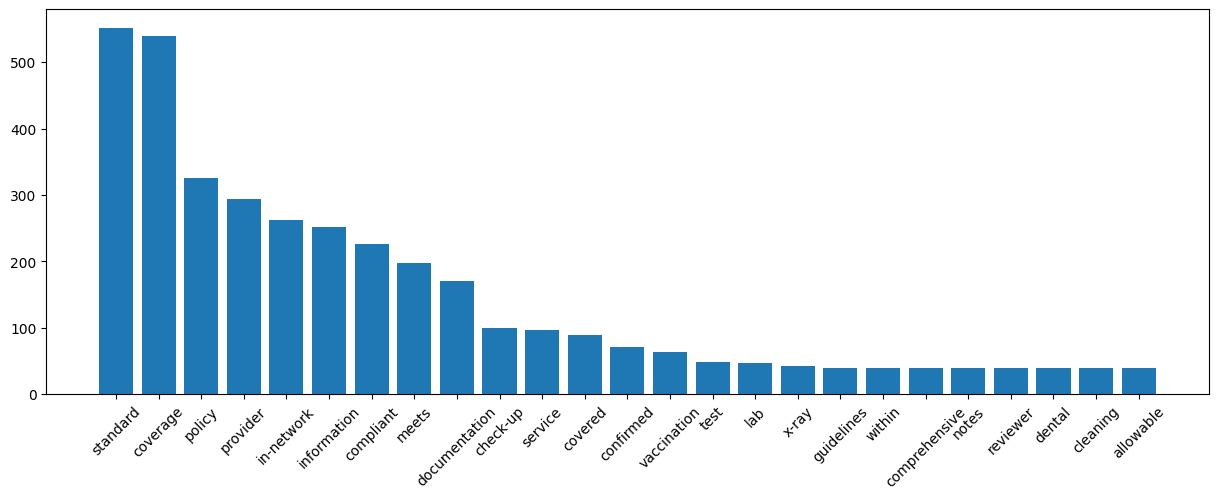

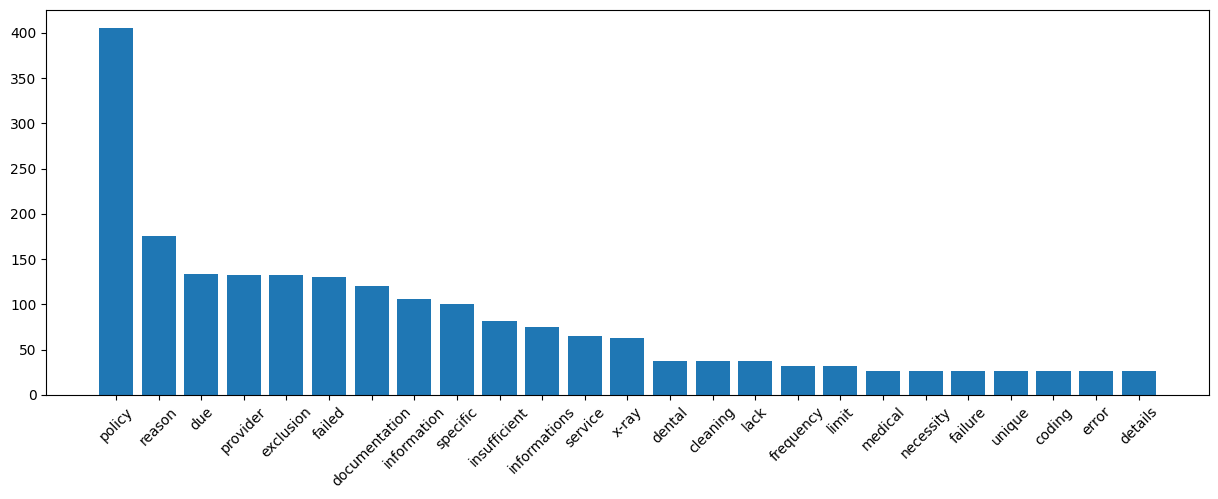

In [ ]:
#Lets map the token frequencies for each approved and denied categories
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import re
from collections import Counter

nltk.download('punkt_tab')

approval_counter = Counter()
denial_counter = Counter()

#removing stop words
nltk.download('stopwords')
nltk.download('wordnet')
stop_words = set(stopwords.words('english'))

custom_stopwords = [
    "member", "mbr", "id", "claim",
    "denied", "denial", "approved"
]

stop_words.update(custom_stopwords)

def clean_tokens(text):
  text = re.sub(r'\b\d{4}-\d{2}-\d{2}\b|\b\d{2}[/-]\d{2}[/-]\d{4}\b', '', text)
  text = re.sub(r'\bmbr-\d+\b', '', text)
  tokens = word_tokenize(text)
  tokens = [token for token in tokens if not token.isdigit()]
  tokens = [re.sub(r'[^\w\s\-]', '', token) for token in tokens if re.sub(r'[^\w\s]', '', token)]
  cleaned_tokens = [token for token in tokens if token not in stop_words]
  return cleaned_tokens

nlp_df_approved['tokens'] = nlp_df_approved['reason'].astype(str).apply(clean_tokens)
nlp_df_denied['tokens'] = nlp_df_denied['reason'].astype(str).apply(clean_tokens)


#approval and denial token frequencies.
for tokens in nlp_df_approved.tokens:
  approval_counter.update(tokens)

for tokens in nlp_df_denied.tokens:
  denial_counter.update(tokens)

# ctr_cleaned = {word:val for word, val in ctr.items() if word not in stop_words}
words, counts = zip(*Counter(approval_counter).most_common(25))
plt.figure(figsize=(15,5))
plt.bar(words, counts)
plt.xticks(rotation=45)


words, counts = zip(*Counter(denial_counter).most_common(25))
plt.figure(figsize=(15,5))
plt.bar(words, counts)
plt.xticks(rotation=45)
plt.show()


plt.show()

### N-Gram Patterns

In [ ]:
nlp_df_approved['clean_reason'] = [" ".join(tokens) for tokens in nlp_df_approved['tokens']]
nlp_df_denied['clean_reason'] = [" ".join(tokens) for tokens in nlp_df_denied['tokens']]

#We exclude common reasons to avoid any bias in our clustering. We will take these into consideration after clustering the unique reasonings
exclusion.extend(["service check-up covered standard coverage provider compliant", "standard coverage check-up confirmed policy requirements met per plan"])
nlp_df_approved = nlp_df_approved[~nlp_df_approved['clean_reason'].isin(exclusion)]
review_approved = nlp_df_approved.groupby(['claimstatus', 'clean_reason']).size().reset_index(name='count').sort_values(by='count', ascending=False)
review_denied = nlp_df_denied.groupby(['claimstatus', 'clean_reason']).size().reset_index(name='count').sort_values(by='count', ascending=False)

/tmp/ipykernel_9704/2601493493.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  nlp_df_denied['clean_reason'] = [" ".join(tokens) for tokens in nlp_df_denied['tokens']]


In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer
import re
from collections import Counter

vectorizer_1 = CountVectorizer(analyzer='word', ngram_range=(2,4))
approval_vect = vectorizer_1.fit_transform(nlp_df_approved['clean_reason'])
counts = approval_vect.sum(axis=0)
ngrams = [(word, counts[0, idx]) for word, idx in vectorizer_1.vocabulary_.items()]
sorted(ngrams, key=lambda x: -x[1])[:10]

[('standard coverage', np.int64(518)),
 ('coverage provider', np.int64(281)),
 ('in network', np.int64(262)),
 ('policy information', np.int64(252)),
 ('information standard', np.int64(252)),
 ('policy information standard', np.int64(252)),
 ('standard coverage provider', np.int64(235)),
 ('information standard coverage', np.int64(227)),
 ('policy information standard coverage', np.int64(227)),
 ('provider in', np.int64(223))]

In [ ]:
approval_vect

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 6488 stored elements and shape (469, 1732)>

In [ ]:
vectorizer_2 = CountVectorizer(analyzer='word', ngram_range=(2, 4))
denial_vect = vectorizer_2.fit_transform(nlp_df_denied['reason'])
counts = denial_vect.sum(axis=0)
ngrams = [(word, counts[0, idx]) for word, idx in vectorizer_2.vocabulary_.items()]
top_ngrams = sorted(ngrams, key=lambda x: -x[1])[:10]
top_ngrams

[('denial reason', np.int64(150)),
 ('due to', np.int64(118)),
 ('policy information', np.int64(106)),
 ('for mbr', np.int64(105)),
 ('policy exclusion', np.int64(90)),
 ('failed policy', np.int64(87)),
 ('mbr mbr', np.int64(80)),
 ('documentation is', np.int64(80)),
 ('is insufficient', np.int64(80)),
 ('documentation is insufficient', np.int64(80))]

## TF-IDF + K-Means Clustering

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

tf_vectorizer = TfidfVectorizer(max_df=0.90, #start 90
                                min_df= 7,#0.015,
                                analyzer = 'word',
                                token_pattern = r"(?u)\b[\w-]+\b",
                                stop_words = ["details", "reason"],
                                ngram_range=(2, 4)) #was 2,6


approval_tf_vect = tf_vectorizer.fit_transform(nlp_df_approved['clean_reason'])

In [ ]:
print(approval_tf_vect.shape)

(341, 222)


Cluster 0: ['confirmed policy requirements met', 'met per', 'confirmed policy', 'requirements met per plan', 'policy requirements met per', 'policy requirements met', 'per plan', 'policy requirements', 'requirements met per', 'requirements met']
Cluster 1: ['standard diagnosticpreventive', 'service within', 'service within policy', 'service within policy allowable', 'necessity supported', 'policy allowable frequency', 'necessity supported in-network provider', 'necessity supported in-network', 'within policy allowable', 'within policy allowable frequency']
Cluster 2: ['standard treatmentpreventive', 'standard preventivediagnostic criteria', 'provider in-network service', 'provider in-network service meets', 'policy information standard treatmentpreventive', 'preventivediagnostic criteria', 'standard preventivediagnostic', 'service meets', 'service meets standard preventivediagnostic', 'service meets standard']
Cluster 3: ['service vaccination', 'standard coverage', 'coverage provider',

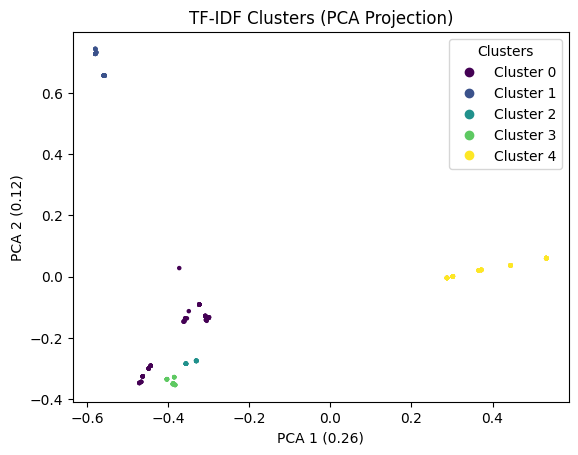

In [ ]:
n_clusters = 5
kmeans = KMeans(n_clusters=n_clusters, random_state=0)
labels = kmeans.fit_predict(approval_tf_vect)
terms = tf_vectorizer.get_feature_names_out()
for i in range(n_clusters):
    top = kmeans.cluster_centers_[i].argsort()[-10:]
    print(f"Cluster {i}:", [terms[j] for j in top])

approval_tf_vect_dense = approval_tf_vect.toarray()
approval_tf_vect_pca = PCA(n_components=2) #.fit_transform(approval_tf_vect_dense)

var_ratio_pca1 = approval_tf_vect_pca.fit(approval_tf_vect_dense).explained_variance_ratio_[0]
var_ratio_pca2 = approval_tf_vect_pca.fit(approval_tf_vect_dense).explained_variance_ratio_[1]
approval_tf_vect_pca = approval_tf_vect_pca.fit_transform(approval_tf_vect_dense)

scatter = plt.scatter(approval_tf_vect_pca[:,0], approval_tf_vect_pca[:,1], c=labels, s=5)
handles, _ = scatter.legend_elements()
legend_labels = [f"Cluster {i}" for i in range(n_clusters)]
plt.legend(handles, legend_labels, title="Clusters")
plt.xlabel(f"PCA 1 ({var_ratio_pca1:.2f})")
plt.ylabel(f"PCA 2 ({var_ratio_pca2:.2f})")
plt.title("TF-IDF Clusters (PCA Projection)")
plt.show()

In [ ]:
approval_df = nlp_df_approved.copy()
approval_df["cluster"] = labels
approval_df["pca1"] = approval_tf_vect_pca[:, 0]
approval_df["pca2"] = approval_tf_vect_pca[:, 1]
approval_df.groupby(['cluster']).size()

,0
cluster,
0,76
1,39
2,25
3,31
4,170


In [ ]:
tf_vectorizer = TfidfVectorizer(max_df=0.90, #start 90
                                min_df=.0015,
                                analyzer = 'word',
                                token_pattern = r"(?u)\b[\w-]+\b",
                                stop_words = ["details", "reason", "dental", "due", "specific"],
                                ngram_range=(2, 5)) #was 2,6

denial_tf_vect = tf_vectorizer.fit_transform(nlp_df_denied['clean_reason'])
print(denial_tf_vect.shape)

(160, 868)


Cluster 0: ['non-compliant policy criteria', 'non-compliant policy criteria refer code', 'refer code', 'found non-compliant policy criteria refer', 'criteria refer', 'criteria refer code', 'found non-compliant policy criteria', 'found non-compliant policy', 'found non-compliant', 'policy criteria']
Cluster 1: ['policy informations', 'policy informations provider', 'provider documentation insufficient policy', 'policy informations provider documentation insufficient', 'failed policy policy informations provider', 'failed policy policy informations', 'policy policy informations', 'policy policy informations provider', 'policy policy informations provider documentation', 'provider documentation insufficient policy information']
Cluster 2: ['failed submit documentation', 'exclusion lack required pre-authorization provider', 'exclusion policy', 'exclusion policy information', 'exclusion lack required pre-authorization', 'documentation support emergency exception', 'emergency exception revie

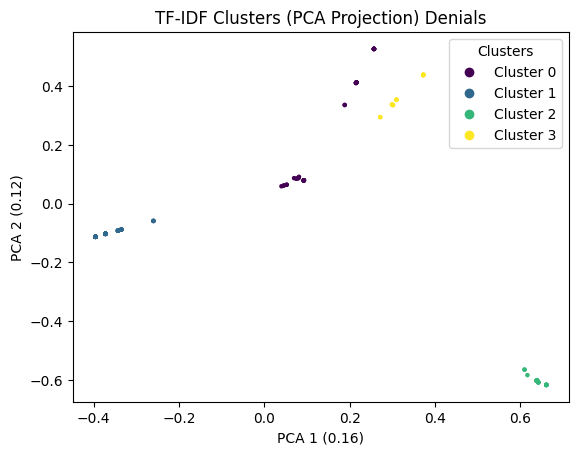

In [ ]:
n_clusters = 4
kmeans = KMeans(n_clusters=n_clusters, random_state=0)
labels = kmeans.fit_predict(denial_tf_vect)
terms = tf_vectorizer.get_feature_names_out()
for i in range(n_clusters):
    top = kmeans.cluster_centers_[i].argsort()[-10:]
    print(f"Cluster {i}:", [terms[j] for j in top])

denial_tf_vect_dense = denial_tf_vect.toarray()
denial_tf_vect_pca = PCA(n_components=2) #.fit_transform(denial_tf_vect_dense)

var_ratio_pca1 = denial_tf_vect_pca.fit(denial_tf_vect_dense).explained_variance_ratio_[0]
var_ratio_pca2 = denial_tf_vect_pca.fit(denial_tf_vect_dense).explained_variance_ratio_[1]

denial_tf_vect_pca = denial_tf_vect_pca.fit_transform(denial_tf_vect_dense)


scatter = plt.scatter(denial_tf_vect_pca[:,0], denial_tf_vect_pca[:,1], c=labels, s=5)
handles, _ = scatter.legend_elements()
legend_labels = [f"Cluster {i}" for i in range(n_clusters)]
plt.legend(handles, legend_labels, title="Clusters")
plt.xlabel(f"PCA 1 ({var_ratio_pca1:.2f})")
plt.ylabel(f"PCA 2 ({var_ratio_pca2:.2f})")
plt.title("TF-IDF Clusters (PCA Projection) Denials")
plt.show()

In [ ]:

denial_df = nlp_df_denied.copy()
denial_df["cluster"] = labels
denial_df.groupby(['cluster']).size()
# denial_df[denial_df['cluster']==4]

,0
cluster,
0,42
1,75
2,21
3,22


### Topic Modeling & LDA (Exploratory)
- This led me to exploring a clustering solution as seen above with TF-IDF + K-Means Clustering.

In [ ]:
from nltk.stem import WordNetLemmatizer
from gensim import corpora, models
from sklearn.decomposition import LatentDirichletAllocation, NMF
#Latent Dirichlet Allocation (LDA) or NMF
nmf_denial = NMF(n_components=10, random_state=42)
nmf_denial.fit(denial_vect)

nmf_approval = NMF(n_components=10, random_state=42)
nmf_approval.fit(approval_tf_vect)#approval_vect)

NMF(n_components=10, random_state=42)

In [ ]:
def print_topics(model, vectorizer, n_words=10):
    words = vectorizer.get_feature_names_out()
    for i, topic in enumerate(model.components_):
      top_words = [words[j] for j in topic.argsort()[-n_words:][::-1]]
      cleaning = ["reason full", "unique reason full", "per plan",  "met per plan", "met per", "meets required"]
      top_words = [top_word for top_word in top_words if top_word not in cleaning]
      scores = [topic[j] for j in topic.argsort()[-n_words:][::-1]]
      print(f"Topic {i}: {', '.join(top_words)}")

print("Approval Topics")
print_topics(nmf_approval, tf_vectorizer) #vectorizer_1)
print("\nDenial Topics")
print_topics(nmf_denial, vectorizer_2)

Approval Topics
Topic 0: necessity supported, confirmed check-up service, coverage provider in-network documentation, coverage confirmed x-ray service, coverage confirmed x-ray, covered standard, coverage provider in-network, in-network policy, requirements met per, requirements met per plan
Topic 1: in-network documentation compliant, confirmed check-up, confirmed x-ray service within, confirmed x-ray service, benefit provider in-network, medical necessity, medical necessity supported, benefit provider, necessity supported in-network provider, comprehensive coverage confirmed x-ray
Topic 2: coverage guidelines policy information, policy allowable, provider in-network policy, policy information standard treatmentpreventive, policy requirements, in-network service, confirmed check-up service within, coverage lab, in-network provider
Topic 3: information standard treatmentpreventive, cleaning meets standard coverage, guidelines policy, documentation compliant, dental cleaning, covered st